# Klasifikasi Kacamata dan Helm Menggunakan HOG + PCA + Random Forest
Notebook ini adalah versi perbaikan dari `new.ipynb` dengan menggunakan metode ekstraksi fitur HOG (Histogram of Oriented Gradients), reduksi dimensi PCA, dan pembatasan max_depth pada Random Forest untuk mencegah overfitting.

In [1]:
import cv2
import numpy as np
import os
import glob
from tqdm.notebook import tqdm
from skimage.feature import hog

IMG_SIZE = (64, 64)

def extract_features_hog(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    # Resize dan konversi ke Grayscale
    img_resized = cv2.resize(img, IMG_SIZE)
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    
    # Ekstraksi fitur HOG (Histogram of Oriented Gradients)
    # Tidak menggunakan thresholding OTSU secara agresif agar bentuk asli tidak hilang
    features = hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
    return features

train_dir = "dataset/train"
categories = {"helm": 0, "kacamata": 1}

X_train_list = []
y_train_list = []

for label_name, label_id in categories.items():
    folder = os.path.join(train_dir, label_name)
    files = glob.glob(os.path.join(folder, "*.*"))
    print(f"Memproses '{label_name}': {len(files)} gambar ditemukan...")

    for img_path in tqdm(files, desc=f"Ekstraksi {label_name}"):
        features = extract_features_hog(img_path)
        if features is not None:
            X_train_list.append(features)
            y_train_list.append(label_id)

X = np.array(X_train_list)
y = np.array(y_train_list)

print(f"\nEkstraksi selesai! Dimensi Matriks Fitur Asli (X): {X.shape}")


Memproses 'helm': 1436 gambar ditemukan...


Ekstraksi helm:   0%|          | 0/1436 [00:00<?, ?it/s]

Memproses 'kacamata': 754 gambar ditemukan...


Ekstraksi kacamata:   0%|          | 0/754 [00:00<?, ?it/s]


Ekstraksi selesai! Dimensi Matriks Fitur Asli (X): (2190, 1764)


In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Standarisasi dan PCA...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduksi dimensi menjadi 100 untuk menghindari overfitting
pca = PCA(n_components=100, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimensi Matriks Fitur setelah PCA: {X_pca.shape}")

Standarisasi dan PCA...
Dimensi Matriks Fitur setelah PCA: (2190, 100)


In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier

X_tr, X_val, y_tr, y_val = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

print("Melatih model Random Forest dengan PCA + HOG...")
# Tambahkan max_depth untuk mencegah terlalu overfitting pada noise
rf_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_tr, y_tr)

val_acc = rf_model.score(X_val, y_val)
print(f"Akurasi pada data validasi internal (20%): {val_acc*100:.2f}%")

cv_scores = cross_val_score(rf_model, X_pca, y, cv=5, scoring='accuracy', n_jobs=-1)
print(f"5-Fold CV Scores: {[round(s*100, 2) for s in cv_scores]}")
print(f"Rata-rata CV Accuracy: {cv_scores.mean()*100:.2f}%")

Melatih model Random Forest dengan PCA + HOG...
Akurasi pada data validasi internal (20%): 93.38%
5-Fold CV Scores: [np.float64(79.68), np.float64(81.96), np.float64(84.02), np.float64(53.65), np.float64(68.04)]
Rata-rata CV Accuracy: 73.47%


=== DEMO KLASIFIKASI ===


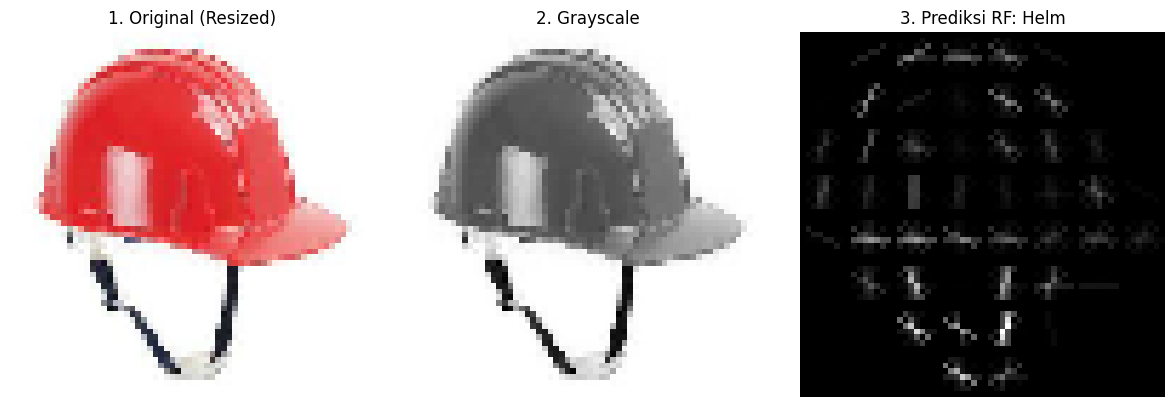

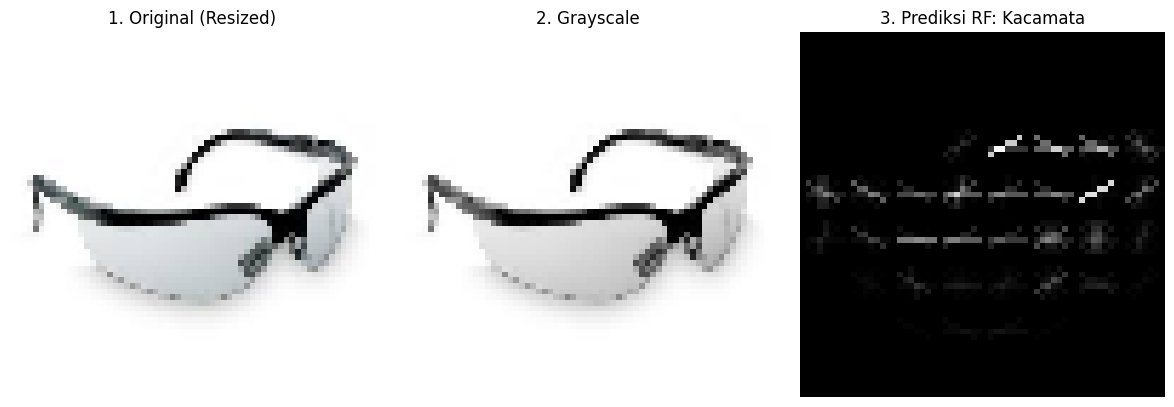

In [4]:
import matplotlib.pyplot as plt 

def classify_and_visualize_hog(image_path, model, pca_model, scaler_model):
    img = cv2.imread(image_path)
    if img is None:
        return "Error"

    img_resized = cv2.resize(img, IMG_SIZE)
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    
    features, hog_image = hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)

    features_scaled = scaler_model.transform([features])
    features_pca = pca_model.transform(features_scaled)
    pred_id = model.predict(features_pca)[0]
    predicted_label = "Helm" if pred_id == 0 else "Kacamata"

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)); axes[0].set_title("1. Original (Resized)")
    axes[1].imshow(img_gray, cmap="gray"); axes[1].set_title("2. Grayscale")
    axes[2].imshow(hog_image, cmap="gray"); axes[2].set_title(f"3. Prediksi RF: {predicted_label}")
    
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    return predicted_label

print("=== DEMO KLASIFIKASI ===")
helm_samples = glob.glob("dataset/test/helm/*.*")
if helm_samples:
    classify_and_visualize_hog(helm_samples[0], rf_model, pca, scaler)

kaca_samples = glob.glob("dataset/test/kacamata/*.*")
if kaca_samples:
    classify_and_visualize_hog(kaca_samples[0], rf_model, pca, scaler)


Memproses 76 gambar data test...


Evaluasi Test Data:   0%|          | 0/76 [00:00<?, ?it/s]

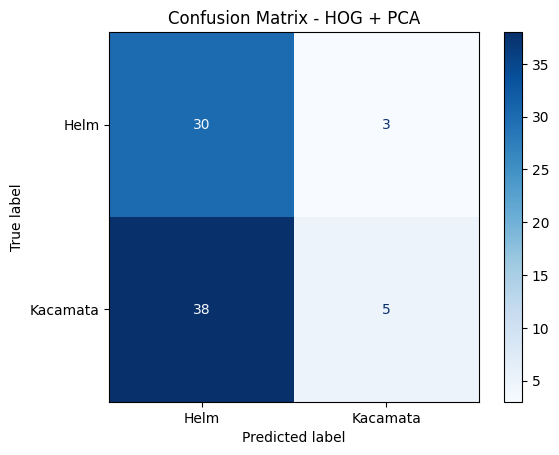


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        Helm       0.44      0.91      0.59        33
    Kacamata       0.62      0.12      0.20        43

    accuracy                           0.46        76
   macro avg       0.53      0.51      0.40        76
weighted avg       0.55      0.46      0.37        76



In [5]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

test_dir = "dataset/test"
test_files = glob.glob(os.path.join(test_dir, "*", "*.*"))

y_true = []
y_pred = []

print(f"Memproses {len(test_files)} gambar data test...")

for img_path in tqdm(test_files, desc="Evaluasi Test Data"):
    parent = os.path.basename(os.path.dirname(img_path))
    actual = "Helm" if parent.lower() == "helm" else "Kacamata"
    y_true.append(actual)
    
    img = cv2.imread(img_path)
    if img is not None:
        features = extract_features_hog(img_path)
        features_scaled = scaler.transform([features])
        features_pca = pca.transform(features_scaled)
        
        pred_id = rf_model.predict(features_pca)[0]
        pred = "Helm" if pred_id == 0 else "Kacamata"
        y_pred.append(pred)
    else:
        y_pred.append("Error")

labels = ["Helm", "Kacamata"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - HOG + PCA")
plt.show()

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
